# Support Vector Machine (SVM)
- Support Vector Machine (SVM) is a powerful supervised learning algorithm primarily used for classification and regression tasks. It works by finding the optimal hyperplane that best separates the data into classes.

#### Key Concepts:
1. Decision Boundary:
    - SVM aims to find the hyperplane (a line in 2D, a plane in 3D, or a higher-dimensional surface) that best separates the data points of different classes with the largest possible margin.

2. Margin:
    - The margin is the distance between the hyperplane and the nearest data points from each class (these nearest points are called support vectors).

    - The goal is to maximize the margin while ensuring that the hyperplane is as far away from the closest data points as possible.

    - SVM maximizes this margin, ensuring better generalization and robustness.

3. Support Vectors:
    - These are the data points closest to the hyperplane. They are critical in defining the position of the hyperplane and, therefore, the decision boundary.

4. Linear and Non-Linear Separation:
    - SVM can handle both linearly separable and non-linearly separable data.

    - Linear SVMs can only separate data that can be separated by a linear hyperplane.

    - For non-linear cases, SVM uses the kernel trick to map the data to a higher-dimensional space where a linear hyperplane can separate the classes.

#### Kernel Trick:
- The kernel trick allows SVM to compute the separation boundary in high-dimensional spaces without explicitly transforming the data. Common kernels include:

    - Linear Kernel: For linearly separable data.

    - Polynomial Kernel: For curved decision boundaries.
    
    - Radial Basis Function (RBF) Kernel: For complex, non-linear boundaries.

#### Use Cases of SVM:
1. Classification:
    - Spam email detection.

    - Face recognition.

    - Fraud detection.

2. Regression:
    - Predicting continuous values (e.g., house prices).

3. Outlier Detection:
    - Identifying anomalies in datasets.

#### Advantages:
1. Effective for high-dimensional data.

2. Works well with small to medium-sized datasets.

3. Robust to overfitting, especially when the number of features is greater than the number of samples.

#### Disadvantages:
1. Computationally intensive for large datasets.

2. Choosing the right kernel and parameters (e.g., regularization, kernel type) requires expertise and experimentation.

3. Sensitive to noise, especially when the data points are not well-separated.

## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()

## Loading the data

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
dataset

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


## Splitting the dataset into training and test sets

In [3]:
from sklearn.model_selection import train_test_split

X = dataset.iloc[:, :2].values
y = dataset.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Feature scaling

In [4]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Training the SVM model on the training set

In [5]:
from sklearn.svm import SVC

classifier = SVC(kernel = 'linear', random_state = 0, verbose=True)
classifier.fit(X_train, y_train)

[LibSVM]*
optimization finished, #iter = 213
obj = -137.745161, rho = -0.712944
nSV = 140, nBSV = 137
Total nSV = 140


SVC(kernel='linear', random_state=0, verbose=True)

## Predicting a new result

In [6]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


## Predicting the test result

In [7]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 1]]


## Making the confusion matrix

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
# Summary Table
cm_table = pd.DataFrame(cm, index=['Wrong Prediction', 'Correct Prediction'], columns=['Predicted No', 'Predicted Yes'])
cm_table

,Predicted No,Predicted Yes
Wrong Prediction,57,1
Correct Prediction,6,16


## Calculating the accuracy score

In [9]:
from sklearn.metrics import accuracy_score

print(f'Model Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%')

Model Accuracy: 91.25%


## Visualizing the training set results

/var/folders/x4/dd2xz8_d4fjbb7kzdq5sp8_40000gn/T/ipykernel_15641/2711413357.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


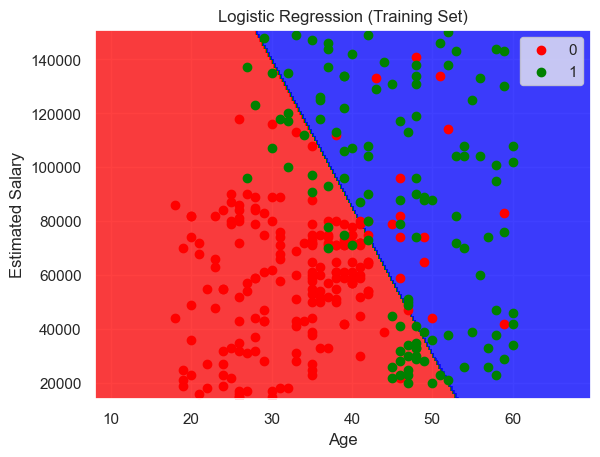

In [10]:
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap


X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))


plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)

plt.title('Logistic Regression (Training Set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Visualizing the test set results

/var/folders/x4/dd2xz8_d4fjbb7kzdq5sp8_40000gn/T/ipykernel_15641/1048508887.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


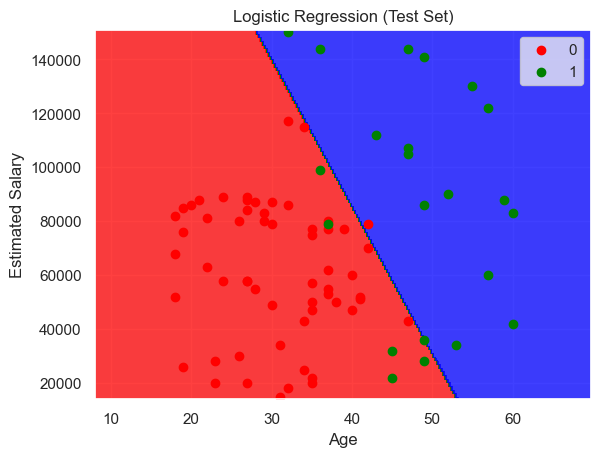

In [11]:
from matplotlib.colors import ListedColormap


X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green', 'blue')))


plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green', 'blue'))(i), label = j)

plt.title('Logistic Regression (Test Set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()